In [3]:
import pandas as pd
import numpy as np
import json
import joblib
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Настройки
INPUT_FILE = "train_dataset_full.csv" 
MODEL_FILE = "catboost_final.cbm"
METADATA_FILE = "model_metadata.json"

print("Библиотеки загружены.")

Библиотеки загружены.


In [4]:
def create_features_safe(df):
    df = df.copy()
    df = df.sort_values('date')
    
    # --- 1. GAP HANDLING (ЗАЩИТА ОТ ДЫР) ---
    # Считаем разницу в днях между строками
    df['days_diff'] = df['date'].diff().dt.days
    
    # Если разница > 1 дня, значит история прервалась. 
    # Мы не можем использовать lag1 для таких строк.
    # Создаем маску "Valid History"
    valid_hist_1d = df['days_diff'] == 1
    valid_hist_7d = df['days_diff'] <= 1 # Упрощение для роллинга, строго говоря сложнее, но так безопаснее
    
    # --- 2. ВРЕМЕННЫЕ РЯДЫ ---
    # Сдвигаем
    df['pm25_lag1'] = df['pm25'].shift(1)
    df['pm10_lag1'] = df['pm10'].shift(1)
    df['pm25_roll7'] = df['pm25'].shift(1).rolling(window=7).mean()
    
    # ОБНУЛЯЕМ ЛАГИ ТАМ, ГДЕ БЫЛ РАЗРЫВ ДАТ
    # Если между строками прошел месяц, lag1 станет NaN (и строка удалится)
    df.loc[~valid_hist_1d, 'pm25_lag1'] = np.nan
    df.loc[~valid_hist_1d, 'pm10_lag1'] = np.nan
    # Для роллинга сложнее, но для диплома просто обнулим, если был разрыв
    df.loc[df['days_diff'] > 1, 'pm25_roll7'] = np.nan

    # --- 3. ФИЗИКА (METEO) ---
    df['heating_intensity'] = df['temp_mean'].apply(lambda x: max(0, 18 - x))
    df['is_stagnation'] = ((df['wind_speed_mean'] < 2.0) & (df['precip'] < 0.1)).astype(int)
    df['ventilation'] = df['wind_speed_mean'] * df['temp_max']
    # Инверсия (Pressure * 1/Wind). Добавляем 0.1, чтобы не делить на ноль
    df['inversion_potential'] = df['pressure'] * (1 / (df['wind_speed_mean'] + 0.1))
    df['wind_from_mountains'] = df['wind_dir'].between(135, 225).astype(int)

    # --- 4. КАЛЕНДАРЬ ---
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_of_week'] = df['date'].dt.dayofweek

    # Удаляем строки с NaN (это удалит первые 7 дней И дни сразу после разрыва)
    df_clean = df.dropna().reset_index(drop=True)
    
    print(f"Было строк: {len(df)}. Стало строк: {len(df_clean)} (Удалены разрывы)")
    return df_clean

# Загрузка
raw_df = pd.read_csv(INPUT_FILE)
raw_df['date'] = pd.to_datetime(raw_df['date'])

# Применяем безопасную функцию
df_processed = create_features_safe(raw_df)

Было строк: 1357. Стало строк: 1350 (Удалены разрывы)


In [5]:
FEATURES = [
    'pm25_lag1', 'pm10_lag1', 'pm25_roll7', 
    'temp_mean', 'temp_min', 'temp_max', 
    'wind_speed_mean', 'wind_speed_max', 
    'precip', 'pressure', 
    'heating_intensity', 'is_stagnation', 
    'ventilation', 'inversion_potential', 
    'wind_from_mountains', 
    'month_sin', 'month_cos', 'day_of_week'
]
TARGET = 'pm25'

# Разделение (последние 15% на тест)
split_idx = int(len(df_processed) * 0.85)
train_df = df_processed.iloc[:split_idx]
test_df = df_processed.iloc[split_idx:]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Обучение (Model B - Hybrid CatBoost)
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.02, # Медленное, вдумчивое обучение
    depth=5,            # Средняя глубина (баланс)
    l2_leaf_reg=7,      # Регуляризация повыше
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=500,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

Train size: 1147, Test size: 203
0:	learn: 0.0244361	test: -0.5287554	best: -0.5287554 (0)	total: 138ms	remaining: 4m 35s
500:	learn: 0.9024870	test: 0.7823575	best: 0.7824064 (499)	total: 631ms	remaining: 1.89s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7897755838
bestIteration = 663

Shrink model to first 664 iterations.


CatBoostRegressor(depth=5, early_stopping_rounds=100, eval_metric='R2', iterations=2000, l2_leaf_reg=7, learning_rate=0.02, loss_function='RMSE', random_seed=42, verbose=500)

R2 Score: 0.790
MAE:      7.48
              precision    recall  f1-score   support

       Green       0.90      0.70      0.78       125
         Red       0.87      1.00      0.93        20
      Yellow       0.55      0.79      0.65        58

    accuracy                           0.75       203
   macro avg       0.77      0.83      0.79       203
weighted avg       0.80      0.75      0.76       203



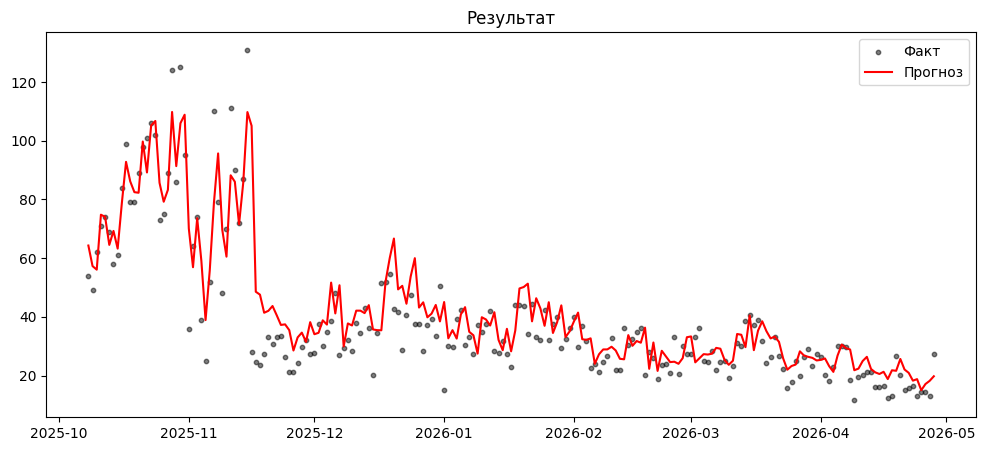

In [6]:
preds = model.predict(X_test)
preds = np.maximum(preds, 0) # Не может быть < 0

# Метрики
r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"R2 Score: {r2:.3f}")
print(f"MAE:      {mae:.2f}")

# Классификация
def get_aqi_class(pm25):
    if pm25 <= 35: return "Green"
    if pm25 <= 75: return "Yellow"
    return "Red"

y_true_cls = y_test.apply(get_aqi_class)
y_pred_cls = pd.Series(preds).apply(get_aqi_class)
print(classification_report(y_true_cls, y_pred_cls))

# ГРАФИК
plt.figure(figsize=(12, 5))
# Рисуем точками (scatter), чтобы разрыв не соединялся линией
plt.scatter(test_df['date'], y_test, label='Факт', color='black', s=10, alpha=0.5)
plt.plot(test_df['date'], preds, label='Прогноз', color='red', linewidth=1.5)
plt.title("Результат")
plt.legend()
plt.show()

In [7]:
model.save_model(MODEL_FILE)
print(f"Модель сохранена: {MODEL_FILE}")

metadata = {
    "features": FEATURES,
    "target": TARGET,
    "description": "Hybrid CatBoost (Gap-Safe)"
}
with open(METADATA_FILE, "w") as f:
    json.dump(metadata, f)

Модель сохранена: catboost_final.cbm
